<a href="https://colab.research.google.com/github/MokshShah25/sms-spam-detection/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

In [127]:
import pandas as pd

In [128]:
df = pd.read_csv("spam.csv",encoding="latin-1")

In [129]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3438,ham,"awesome, how do I deal with the gate? Charles ...",NaN,NaN,NaN
1618,ham,The 2 oz guy is being kinda flaky but one frie...,NaN,NaN,NaN
5514,ham,Oh... Okie lor...We go on sat...,NaN,NaN,NaN
1413,spam,Dear U've been invited to XCHAT. This is our f...,NaN,NaN,NaN
2340,ham,I will take care of financial problem.i will h...,NaN,NaN,NaN


In [130]:
df.shape

(5572, 5)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [132]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [133]:
df.v1.value_counts()

,count
v1,
ham,4825
spam,747


In [134]:
df.sample()

,v1,v2
4925,ham,"Oh yes, why is it like torture watching england?"


In [135]:
df.rename(columns={
    "v1":"target",
    "v2":"text"
},inplace=True)

In [136]:

df.sample()

,target,text
575,spam,"You have won ?1,000 cash or a ?2,000 prize! To..."


In [137]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [138]:
df["target"] = encoder.fit_transform(df["target"])

In [139]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [140]:
df.duplicated().sum()

np.int64(403)

In [141]:
df.drop_duplicates(inplace=True)

In [142]:
df.duplicated().sum()

np.int64(0)

In [143]:
df.shape

(5169, 2)

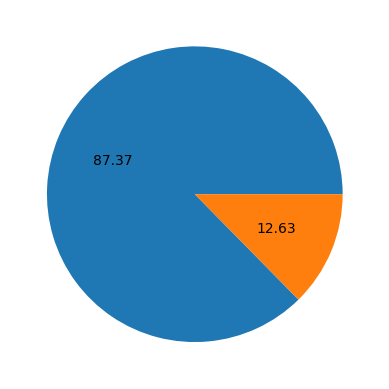

In [144]:
import matplotlib.pyplot as plt
plt.pie(df["target"].value_counts(),autopct="%0.2f")
plt.show()

In [145]:
import nltk

In [146]:
nltk.download('punkt_tab')
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [147]:
df["num_character"] = df["text"].apply(len)

In [148]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [149]:
df["num_words"] = df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [150]:
df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [151]:
df.text[0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [152]:
df["num_sentence"] = df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [153]:
df.sample(5)

,target,text,num_character,num_words,num_sentence
4768,0,watever reLation u built up in dis world only ...,120,23,2
1340,0,Might ax well im there.,23,6,1
1098,0,NO GIFTS!! You trying to get me to throw mysel...,73,18,2
5417,0,Nope. I just forgot. Will show next week,40,10,3
1360,0,Yo dude guess who just got arrested the other day,49,10,1


In [154]:
import seaborn as sns

<Axes: xlabel='num_character', ylabel='Count'>

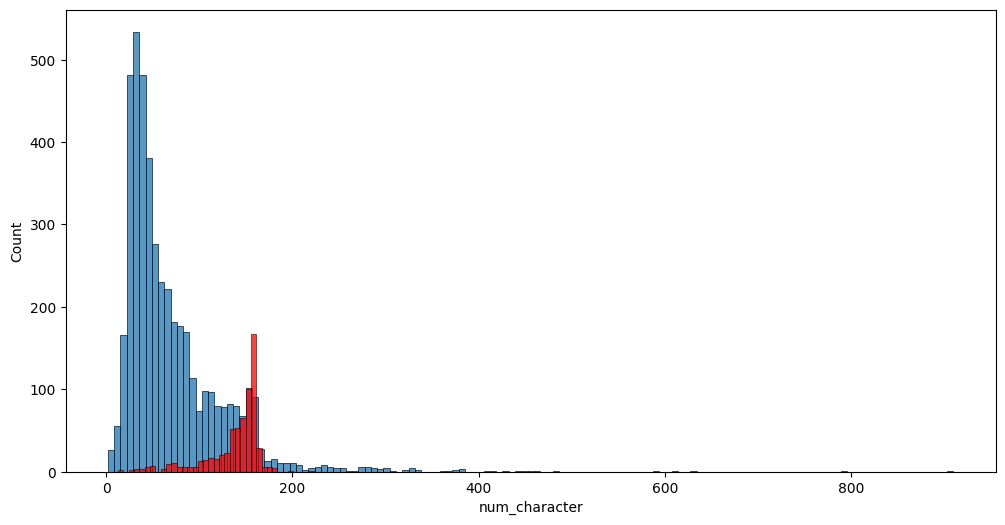

In [155]:
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"] == 0]["num_character"])
sns.histplot(df[df["target"] == 1]["num_character"],color = "red")

In [156]:
# Data Preprocessing
# Lower case
# Tokenization
# Removing special characters
# Removing stop words and punctuation
# Stemming

In [157]:
def text_transform(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words("english") and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

In [158]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import  PorterStemmer
ps = PorterStemmer()

In [159]:
df["transformed"] = df["text"].apply(text_transform)

In [160]:
df.head()

,target,text,num_character,num_words,num_sentence,transformed
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [161]:
from wordcloud import  WordCloud
wc = WordCloud(width = 500,height=500,min_font_size=10,background_color="white")

In [162]:
spam_wc = wc.generate(df[df["target"] == 1]["transformed"].str.cat(sep = " "))

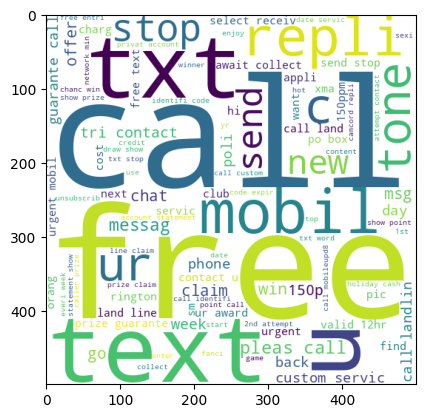

In [163]:
plt.imshow(spam_wc)

In [197]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [198]:
# x = cv.fit_transform(df["transformed"]).toarray()
x = tfidf.fit_transform(df["transformed"]).toarray()

In [199]:
x.shape

(5169, 3000)

In [200]:
y = df["target"].values

In [201]:
from sklearn.model_selection import train_test_split

In [202]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=2,test_size=0.2)

In [203]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [204]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [205]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [206]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [207]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [208]:
import pickle

In [210]:
pickle.dump(tfidf,open("vectorizer.pkl","wb"))
pickle.dump(mnb,open("model.pkl","wb"))